In [1]:
import os
from io import BytesIO
import requests
from datetime import datetime,timedelta
import warnings
import xarray as xr
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
import pandas as pd
import matplotlib.patheffects as path_effects
from matplotlib.colors import ListedColormap
from matplotlib.colorbar import ColorbarBase
import matplotlib.colors as mcolors
#import image_functions as imagef
#import plotting_functions as plotf
import helper_dicts as hdict
import helper_functions as helper
%load_ext autoreload
%autoreload 2
import cftime
import dask
import rioxarray

In [2]:
figure_dir = '/cpc/int_desk/pac_isl/stations/images'
gefs_dir = '/cpc/africawrf/ebekele/cca/xcast/subseason/prep_data/data/'
gefs_raw_dir = '/cpc/africawrf/ebekele/projects/PREPARE_pacific/subseason_unmasked/'

In [16]:
#from Endalks's ctl file for cmorph
gefs_prd = '/cpc/gth/GTH_WK34/GEFSv12/precip/'
xdimgef = 720
ydimgef = 361
xmingef= 0
xmaxgef=360
ymingef=-90
ymaxgef=0.5
zdimgef = 15
c_date = datetime.now().date()
print(c_date)
c_month = c_date.month
c_day = c_date.day
if c_month < 10:
    c_month = '0' + str(c_month)
else: c_month = str(c_month)
if c_day < 10:
    c_day = '0' + str(c_day)
else: c_day = str(c_day)
date_str = str(c_date.year) + c_month + c_day
date_str

2025-02-03


'20250203'

In [18]:
def read_in_binary_gefs(location, xdim, ydim, zdim, xmin, xmax, ymin, ymax):
    if os.path.exists(location):
        with open(location, 'rb') as binary_file:
            binary_data = binary_file.read()
        data = np.frombuffer(binary_data, dtype = np.float32)

        # Ensure the correct number of elements in the data
        total_elements = len(binary_data) // 4  # 4 bytes per float32
        expected_elements = xdim * ydim * zdim
        if total_elements != expected_elements:
            raise ValueError(f"Mismatch in data size: expected {expected_elements} elements, got {total_elements}.")
        data = data.reshape(zdim,ydim,xdim)
        lat = np.linspace(ymin, ymax, data.shape[1])
        lon = np.linspace(xmin, xmax, data.shape[2])
        var = np.linspace(1,zdim,data.shape[0])
        da = xr.DataArray(data, dims = ['var','lat', 'lon'], coords = {'lat': lat, 'lon':lon, 'var':var})
        return da

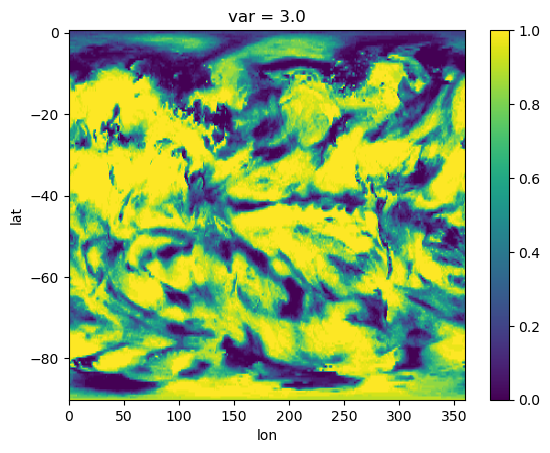

In [19]:
da = read_in_binary_gefs(gefs_raw_dir + 'gefs_week1_precip_' + date_str + 'IC.dat', xdimgef, ydimgef, zdimgef, xmingef, xmaxgef, ymingef, ymaxgef)
clim = da.isel(var=0)
total = da.isel(var =1)
rawabv= da.isel(var=2)
calibabv=da.isel(var=3)
prob10 = da.isel(var=4) #prob exceedence 10 mm
prob25 = da.isel(var=5) #prob exceedance 25 mm ...
prob50 = da.isel(var=6)
prob100 = da.isel(var=7)
prob150 = da.isel(var=8)
prob200 = da.isel(var=9)
# prob20 = da.isel(var=10)
# prob30 = da.isel(var=11)
# prob40 = da.isel(var=12)
# prob75 = da.isel(var=13)
corr = da.isel(var=14)
prcpwk1_anom = total = clim
prcpwk1abv = rawabv
prcpwk1blw = 1 - prcpwk1abv
prcpwk1blw.plot()

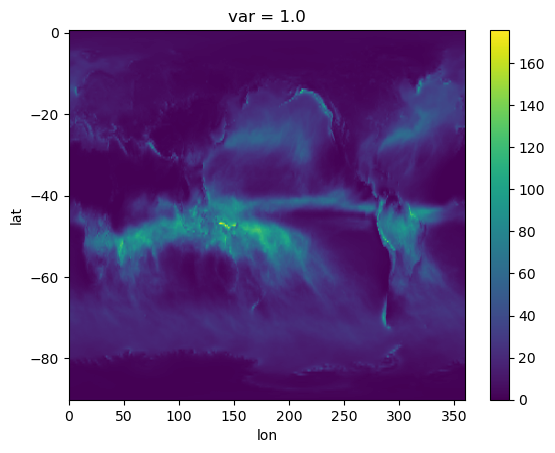

In [21]:
total.plot()

In [34]:
from matplotlib.colors import BoundaryNorm, ListedColormap
ptotal_colors = [
    (254/255, 254/255, 254/255), #off white
    (198/255, 252/255, 188/255), #light green
    (118/255, 241/255, 113/255), #bright green
    (29/255, 178/255,  29/255), #dark green
    (178/255, 238/255, 248/255), #light blue
    (79/255, 163/255, 243/255), #med blue
    (29/255, 108/255, 231/255), #darker blue
    (236/255, 228/255, 238/255), #light purple
    (158/255, 139/255, 253/255), #bright purple
    (110/255,  94/255, 216/255), #dark purple
    (253/255, 248/255, 168/255), #light yellow
    (250/255, 156/255,   0/255), #orange
    (223/255,  19/255,   0/255), #bright red
    (163/255,   0/255,   0/255), #dark red
    (227/255, 138/255, 138/255), #rose
    (244/255, 232/255, 232/255) #light pink
]
ptotal_intervals = [0, 2, 5, 10, 25, 50, 75, 100,
                    150, 200, 300, 500, 750,1000,
                    1500, 2500, 3500]
gefs_totalp = total.to_dataset(name = 'tp')
gefs_totalp = gefs_totalp.rename({'lon':'x', 'lat':'y'})
gefs_total_crs = gefs_totalp.rio.write_crs('EPSG:4326', inplace = True)
gefs_totalp = gefs_total_crs.sel(x=slice(0,359.999), y = slice(-59,59))
gefs_tp_mc = fc.convert_to_mercator(gefs_totalp, 'tp')
gefs_tpnorm = np.clip(gefs_tp_mc.tp, 0, 3500)
total_cmap = ListedColormap(ptotal_colors, N=len(ptotal_colors))
total_norm = BoundaryNorm(boundaries=ptotal_intervals, ncolors=len(ptotal_colors))
total_rgb = colors.apply_colormap(totalnorm, total_cmap, total_norm, ptotal_intervals)
last90_rgb.rio.to_raster(os.path.join(figure_dir, 'cmorph90anom.tif'), dtype="uint8")

NameError: name 'colors' is not defined

In [25]:
ge'/cpc/africawrf/ebekele/projects/PREPARE_pacific/subseason_unmasked'

In [2]:
test = xr.open_dataset('/cpc/africawrf/ebekele/projects/PREPARE_pacific/subseason_unmasked/gefs_week1_precip_20250131IC.dat')

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib', 'rasterio']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [3]:
def getYears(start, end):
    #start year, to end year inclusive
    # >get YearStrings ("1981", "1982"... "2016")
    #return [expression for var is iterable if condition]
    return [year for year in range(start, end+1)]

In [149]:
import glob
import xarray as xr
current_year = datetime.now().year
# Define the file path pattern for the specific years you want
total_years = range(1991, current_year + 1)  # years between 1982 and 2020 inclusive
climyear1 = 1991
climyear2 = 2020
files = [f"/cpc/int_desk/data/oisstv2/sst.day.mean.{year}.nc" for year in total_years]

# Use xarray to open the files
sst_daily = xr.open_mfdataset(files, engine = "netcdf4",combine='by_coords', chunks = {"lat":720, "lon":1440, "time":100})

In [255]:
sst_daily

<xarray.Dataset>
Dimensions:  (time: 12375, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 1991-01-01 1991-01-02 ... 2024-11-17
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 dask.array<chunksize=(100, 720, 1440), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.5
    title:          NOAA High-resolution Blended Analysis: Daily Values using...
    institution:    NOAA/NCDC
    source:         NOAA/NCDC  ftp://eclipse.ncdc.noaa.gov/pub/OI-daily-v2/
    history:        Thu Aug 24 13:40:21 2017: ncatted -O -a References,global...
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

In [275]:
# Step 1: Select the climatology data for the fixed baseline period (1991-2020)
sst_clim_baseline = sst_daily.sel(time=sst_daily.time.dt.year.isin(range(climyear1, climyear2 + 1)))

# Step 2: Compute the mean climatology by day of the year for the baseline period (1991-2020)
sst_clim_mean = sst_clim_baseline.groupby('time.dayofyear').mean(dim='time')

# Step 3: Compute the day of year for each time in the original SST dataset
sst_daily_dayofyear = sst_daily.time.dt.dayofyear

# Step 4: Expand the climatology to match the time dimension of sst_daily, maintaining the same day-of-year values
sst_climatology_expanded = sst_clim_mean.sel(dayofyear=sst_daily_dayofyear)

# Ensure that climatology is expanded across all the time steps in sst_daily
# sst_climatology_expanded = sst_climatology_expanded.expand_dims(time=sst_daily.time)

# Step 5: Calculate the anomaly by subtracting the climatological baseline from the original SST values
sst_anomaly = sst_daily - sst_climatology_expanded

# Step 6: Calculate 7-day and 14-day anomalies (if needed)
sst_anom_7 = sst_anomaly.isel(time=slice(-7, None)).mean(dim='time')
sst_anom_814 = sst_anomaly.isel(time=slice(-14, -7)).mean(dim='time')
sst_anom_diff = sst_anom_7 - sst_anom_814

# Persist the results if necessary
sst_anom_7 = sst_anom_7.persist()
sst_anom_diff = sst_anom_diff.persist()

/cpc/home/kkowal/.conda/envs/map_env/lib/python3.9/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 34 times more chunks
  return self.array[key]


In [276]:
sst_anomaly

<xarray.Dataset>
Dimensions:    (time: 12375, lat: 720, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 1991-01-01 1991-01-02 ... 2024-11-17
  * lat        (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon        (lon) float32 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
    dayofyear  (time) int64 1 2 3 4 5 6 7 8 ... 315 316 317 318 319 320 321 322
Data variables:
    sst        (time, lat, lon) float32 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>

In [140]:
#compute sst anomalies for past 7 days, and diff
with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    clim_years = getYears(climyear1, climyear2)
    sst_daily = sst_daily.sortby('time')
    sst_clim = sst_daily.sel(time=sst_daily.time.dt.year.isin(clim_years))

    sst_clim_mean = sst_clim.sortby('time').groupby('time.dayofyear').mean(dim = 'time')
    # Step 1: Compute the day of year for each time in the original dataset
    sst_daily_dayofyear = sst_daily.time.dt.dayofyear

    # Step 2: Select matching climatology values for each day of the year
    sst_climatology_expanded = sst_clim_mean.sortby('dayofyear').sel(dayofyear=sst_daily_dayofyear)

     # Step 3: Calculate the anomaly by subtracting the climatology from the original dataset
    sst_anomaly = sst_daily.sortby('time') - sst_climatology_expanded.sortby('time')
    sst_anomaly = sst_anomaly.sortby('time')
    sst_anom_7 = sst_anomaly.isel(time=slice(-7,None)).mean(dim='time')
    sst_anom_814 = sst_anomaly.isel(time=slice(-14,-7)).mean(dim='time')
    sst_anom_diff = sst_anom_7 - sst_anom_814
sst_anom_7 = sst_anom_7.persist()
sst_anom_diff = sst_anom_diff.persist()

/cpc/home/kkowal/.conda/envs/map_env/lib/python3.9/site-packages/xarray/core/indexing.py:1374: PerformanceWarning: Slicing with an out-of-order index is generating 33 times more chunks
  return self.array[key]


In [322]:
sst_anom_7.sst.values

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.08295233,  0.05814285,  0.04847619, ...,  0.02461907,
         0.04080951,  0.06580945],
       [ 0.04004766, -0.00219039, -0.01914287, ..., -0.02700002,
        -0.01976194,  0.02300004],
       [-0.06885714, -0.06885714, -0.07090472, ..., -0.07014285,
        -0.06885714, -0.06885714]], dtype=float32)

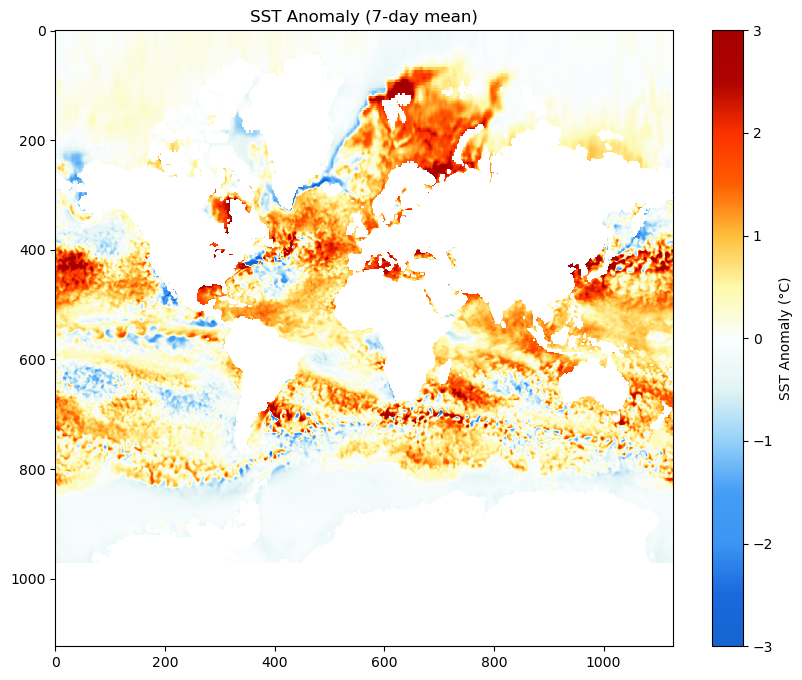

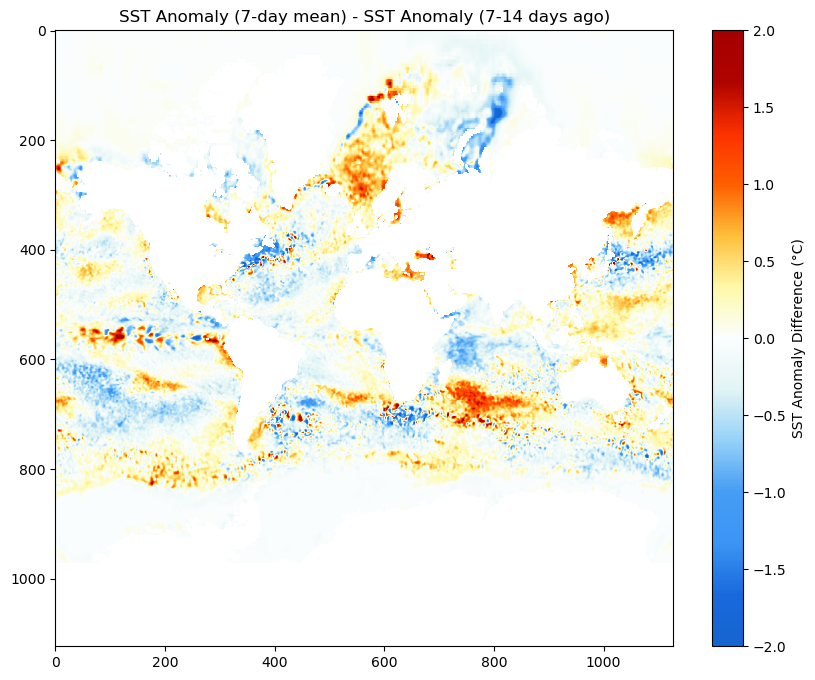

In [319]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Define the colormap
colors = [(21/255, 100/255, 208/255), (25/255, 105/255, 221/255), #dark blue, blue
 (60/255, 149/255, 244/255), (69/255, 157/255, 244/255), #med blue med blue
 (149/255, 209/255,249/255),(226/255, 244/255, 244/255),#lightblue, almost white blue
(251/255, 254/255, 254/255), #off white
(254/255, 249/255, 169/255), (254/255, 191/255,  59/255), #light yellow, light orange
 (254/255,  95/255, 0/255), (253/255,  49/255,0/255), #organce, bright red
 (175/255,   3/255,   0/255), (164/255, 0/255, 0/255)]# dark red, darker red]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_yellow_red", colors)

# Write CRS to the datasets
sst_anom_7_crs = sst_anom_7.rio.write_crs('EPSG:4326', inplace=True)
sst_anom_diff_crs = sst_anom_diff.rio.write_crs('EPSG:4326', inplace=True)

# Rename latitude and longitude dimensions
sst_anom_7_crs = sst_anom_7_crs.rename({'lat': 'y', 'lon': 'x'})
sst_anom_diff_crs = sst_anom_diff_crs.rename({'lat': 'y', 'lon': 'x'})

# Clip to a specific geographic extent and reproject to EPSG:3857 (Mercator)
sst_anom_7_clipped = sst_anom_7_crs.rio.clip_box(minx=0, miny=-85, maxx=360, maxy=85)
sst_anom7_mercator = sst_anom_7_clipped.rio.reproject("EPSG:3857")

sst_anom_diff_clipped = sst_anom_diff_crs.rio.clip_box(minx=0, miny=-85, maxx=360, maxy=85)
sst_anomdiff_mercator = sst_anom_diff_clipped.rio.reproject("EPSG:3857")

# Normalize the data to the desired range e.g. [-2, 2] (e.g., SST diff anomalies)
vmin, vmax = -3, 3
vmindiff, vmaxdiff = -2, 2
sst_7norm = np.clip(sst_anom7_mercator.sst, vmin, vmax)
sst_7diffnorm = np.clip(sst_anomdiff_mercator.sst, vmindiff, vmaxdiff)

# Plot for visualization
plt.figure(figsize=(10, 8))  # Ensure the figure size is appropriate
plt.imshow(sst_7norm, cmap=custom_cmap, vmin=vmin, vmax=vmax)
plt.colorbar(label='SST Anomaly (°C)')
plt.title('SST Anomaly (7-day mean)')

# Plot for visualization
plt.figure(figsize=(10, 8))  # Ensure the figure size is appropriate
plt.imshow(sst_7diffnorm, cmap=custom_cmap, vmin=vmindiff, vmax=vmaxdiff)
plt.colorbar(label='SST Anomaly Difference (°C)')
plt.title('SST Anomaly (7-day mean) - SST Anomaly (7-14 days ago)')

# Apply a colormap (e.g., "RdBu" for anomalies)
cmap = plt.get_cmap(custom_cmap)
sst_7rgb = custom_cmap((sst_7norm - (-3)) / (3 - (-3)))[:, :, :3]  # Normalize the values to [0, 1] for colormap but keep original scale#cmap(sst_7norm)[:, :, :3]  # Extract RGB channels (ignore alpha channel)
sst_7rgb = (sst_7rgb * 255).astype(np.uint8)  # Scale to 0-255 for image representation

sst_7diffrgb = cmap((sst_7diffnorm - (-2)) / (2 - (-2)))[:, :, :3]  # Extract RGB channels (ignore alpha channel)
sst_7diffrgb = (sst_7diffrgb * 255).astype(np.uint8)  # Scale to 0-255 for image representation

# Create an alpha channel for transparency (0 for NaN, 255 for valid data)
sst_7alpha = ~np.isnan(sst_7norm) * 255
sst_7rgba = np.dstack((sst_7rgb, sst_7alpha.astype(np.uint8)))  # Add alpha channel

sst_7diffalpha = ~np.isnan(sst_7diffnorm) * 255
sst_7diffrgba = np.dstack((sst_7diffrgb, sst_7diffalpha.astype(np.uint8)))  # Add alpha channel

# Convert to xarray for export
sst_7rgba_xarray = xr.DataArray(
    sst_7rgba,
    dims=("y", "x", "band"),
    coords={"y": sst_anom7_mercator.y, "x": sst_anom7_mercator.x, "band": [1, 2, 3, 4]},
)
sst_7rgba_xarray = sst_7rgba_xarray.transpose("band", "y", "x").rio.write_crs(sst_anom7_mercator.rio.crs)

sst_7diffrgba_xarray = xr.DataArray(
    sst_7diffrgba,
    dims=("y", "x", "band"),
    coords={"y": sst_anomdiff_mercator.y, "x": sst_anomdiff_mercator.x, "band": [1, 2, 3, 4]},
)
sst_7diffrgba_xarray = sst_7diffrgba_xarray.transpose("band", "y", "x").rio.write_crs(sst_anomdiff_mercator.rio.crs)

# Write to GeoTIFF with transparency
sst_7rgba_xarray.rio.to_raster(os.path.join(figure_dir, 'sst_mercator7.tif'), dtype="uint8")
sst_7diffrgba_xarray.rio.to_raster(os.path.join(figure_dir, 'sst_mercator7diff.tif'), dtype="uint8")


In [328]:
sst_anomdiff

NameError: name 'sst_anomdiff' is not defined

In [329]:
print(sst_anom_7_crs)
print("x range:", sst_anom_7_crs.x.min().values, sst_anom_7_crs.x.max().values)
print("y range:", sst_anom_7_crs.y.min().values, sst_anom_7_crs.y.max().values)

print(sst_anom7_mercator)
print("x range:", sst_anom7_mercator.x.min().values, sst_anom7_mercator.x.max().values)
print("y range:", sst_anom7_mercator.y.min().values, sst_anom7_mercator.y.max().values)

<xarray.Dataset>
Dimensions:      (y: 720, x: 1440)
Coordinates:
  * y            (y) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * x            (x) float32 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
    spatial_ref  int64 0
Data variables:
    sst          (y, x) float32 dask.array<chunksize=(720, 1440), meta=np.ndarray>
x range: 0.125 359.875
y range: -89.875 89.875
<xarray.Dataset>
Dimensions:      (x: 1128, y: 1124)
Coordinates:
  * x            (x) float64 -2.002e+07 -1.998e+07 ... 1.998e+07 2.002e+07
  * y            (y) float64 1.995e+07 1.992e+07 ... -1.991e+07 -1.995e+07
    spatial_ref  int64 0
Data variables:
    sst          (y, x) float32 0.03643 0.02481 0.009095 ... nan nan nan
x range: -20019714.04122391 20019726.062328305
y range: -19946764.02176112 19954103.578716457


<Figure size 500x300 with 0 Axes>

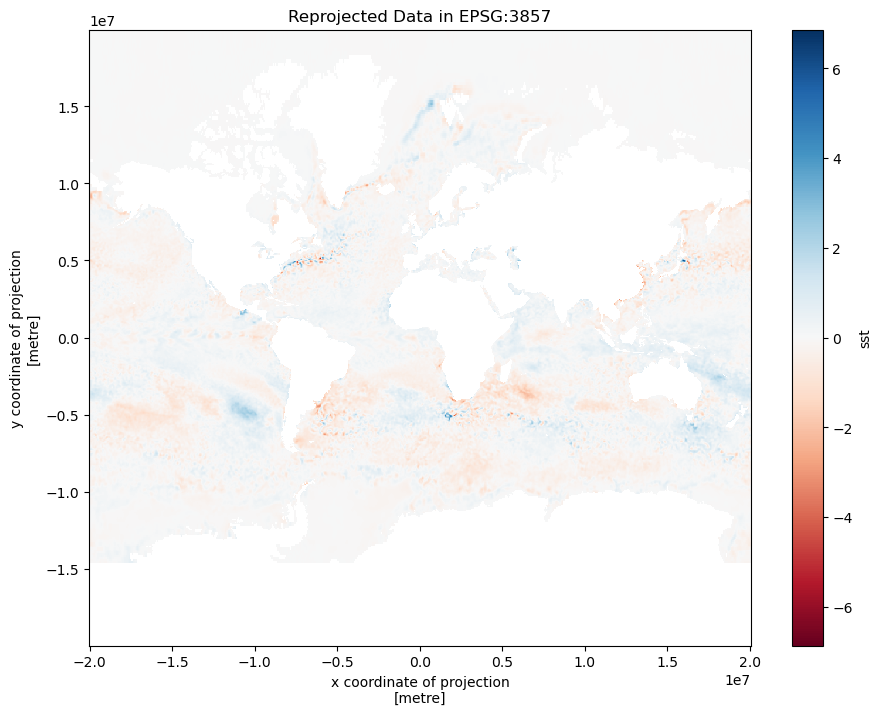

In [200]:
plt.figure(figsize=(5, 3))
sst_anomdiff_mercator.sst.squeeze().plot(cmap='RdBu', size = 8, aspect='auto')  # Adjust the colormap as needed
plt.title("Reprojected Data in EPSG:3857")
plt.show()

In [33]:
sst_anom_7 = sst_anom_7.rio.write_crs('EPSG:4326')
sst_anom7_mercator = sst_anom_7.rio.reproject('EPSG:3857')

sst_anom_diff = sst_anom_diff.rio.write_crs('EPSG:4326')
sst_anom7diff_mercator = sst_anom_diff.rio.reproject('EPSG:3857')



In [ ]:
#command line
# gdal2tiles.py -p mercator -z 0-5 /cpc/int_desk/pac_isl/stations/images/sst_mercator7.tif /cpc/int_desk/pac_isl/stations/images/sst_anom7_tiles
# gdal2tiles.py -p mercator -z 0-5 /cpc/int_desk/pac_isl/stations/images/sst_mercator7diff.tif /cpc/int_desk/pac_isl/stations/images/sst_anom7diff_tiles

In [8]:
gefs_week1 = xr.open_dataset(os.path.join(gefs_dir, 'gefs_week1_fcst.nc'))

<xarray.Dataset>
Dimensions:  (lat: 201, lon: 721, time: 1)
Coordinates:
  * lat      (lat) float32 -50.0 -49.5 -49.0 -48.5 -48.0 ... 48.5 49.0 49.5 50.0
  * lon      (lon) float32 -180.0 -179.5 -179.0 -178.5 ... 179.0 179.5 180.0
  * time     (time) datetime64[ns] 2024-11-08
Data variables:
    precip   (time, lat, lon) float64 ...

#### Get Colors from Images

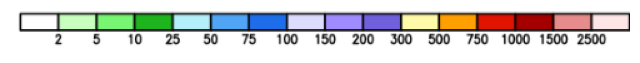

Dominant Colors (RGB):
[[254 254 254]
 [ 64  63  63]
 [ 75 154 230]
 [223  19   0]
 [207 207 207]
 [ 26  28  28]
 [253 158   0]
 [136 136 137]
 [119 243 114]
 [ 29 178  29]
 [227 138 138]
 [158 139 253]
 [253 248 168]
 [111  95 218]
 [ 29 108 231]
 [218 218 253]
 [179 182 183]
 [163   0   0]
 [101 107  92]
 [198 252 188]
 [254 230 229]
 [ 13  15  20]
 [178 238 248]
 [ 13  50 108]
 [ 94   4   0]
 [ 46  47  48]
 [ 13  81  13]
 [117  73   0]
 [ 12   7   3]
 [205 128   0]
 [240 240 240]
 [ 55 113  52]
 [ 82 168  79]
 [110 112 114]
 [ 79 165 245]
 [ 78  68 133]
 [225 221 221]
 [158 159 159]
 [ 86  78  75]
 [ 43  63 109]]


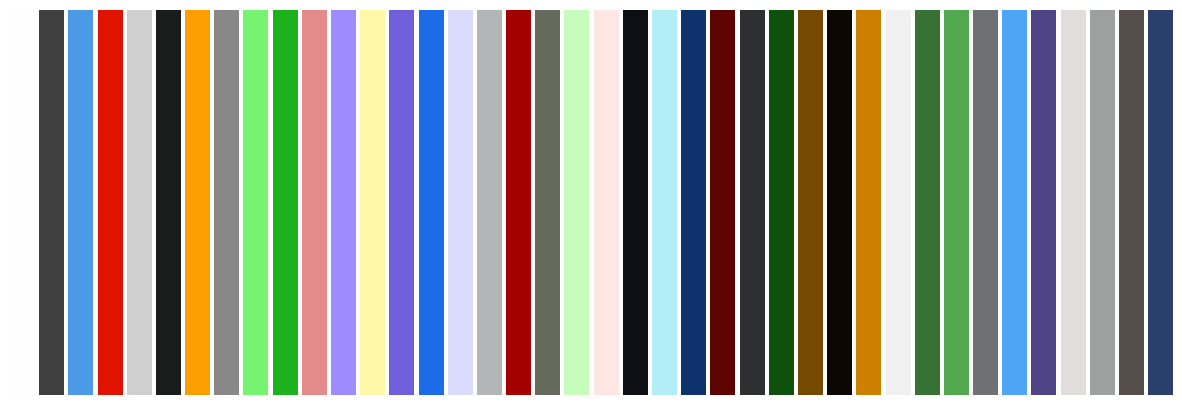

((0.08235294117647059, 0.39215686274509803, 0.8156862745098039),
 (0.09803921568627451, 0.4117647058823529, 0.8666666666666667),
 (0.23529411764705882, 0.5843137254901961, 0.9568627450980393),
 (0.27058823529411763, 0.615686274509804, 0.9568627450980393),
 (0.5843137254901961, 0.8196078431372549, 0.9764705882352941),
 (0.8862745098039215, 0.9568627450980393, 0.9568627450980393),
 (0.984313725490196, 0.996078431372549, 0.996078431372549),
 (0.996078431372549, 0.9764705882352941, 0.6627450980392157),
 (0.996078431372549, 0.7490196078431373, 0.23137254901960785),
 (0.996078431372549, 0.37254901960784315, 0.0),
 (0.9921568627450981, 0.19215686274509805, 0.0),
 (0.6862745098039216, 0.011764705882352941, 0.0),
 (0.6431372549019608, 0.0, 0.0))

In [22]:
import numpy as np
from sklearn.cluster import KMeans
from PIL import Image
import matplotlib.pyplot as plt
import os

def calc_dominant_colors(image_array, n_colors=5):
    # Ensure the image is in RGB mode
    if image_array.mode != 'RGB':
        image_array = image_array.convert('RGB')
    
    # Reshape the array to a list of pixels
    pixels = np.array(image_array).reshape(-1, 3)
    
    # Perform K-means clustering to find the dominant colors
    kmeans = KMeans(n_clusters=n_colors, random_state=0).fit(pixels)
    
    # Get the cluster centers (dominant colors)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    
    return dominant_colors

# Load the image
colorbar = Image.open(os.path.join(figure_dir, 'gefswk1ptotal_legend.png'))

# Plot the original image
plt.figure(figsize=(8, 8))  # You can adjust the figure size as needed
plt.imshow(colorbar)
plt.axis('off')  # Turn off axis to only show the image
plt.show()

# Calculate the dominant colors
dominant_colors = calc_dominant_colors(colorbar, n_colors=40)

# Print the dominant colors
print("Dominant Colors (RGB):")
print(dominant_colors)

# Plot the dominant colors
fig, ax = plt.subplots(1, len(dominant_colors), figsize=(15, 5))
for i, color in enumerate(dominant_colors):
    ax[i].imshow([[color]], aspect='auto')
    ax[i].axis('off')  # Hide axis

plt.show()
((21/255, 100/255, 208/255), (25/255, 105/255, 221/255), #dark blue, blue
 (60/255, 149/255, 244/255), (69/255, 157/255, 244/255), #med blue med blue
 (149/255, 209/255,249/255),(226/255, 244/255, 244/255),#lightblue, almost white blue
(251/255, 254/255, 254/255), #off white
(254/255, 249/255, 169/255), (254/255, 191/255,  59/255), #light yellow, light orange
 (254/255,  95/255, 0/255), (253/255,  49/255,0/255), #organce, bright red
 (175/255,   3/255,   0/255), (164/255, 0/255, 0/255))# dark red, darker red